# Etapa 2 — Análise Exploratória de Dados

Entrada: os CSVs que a Etapa 1 gravou em `../data/raw/`.
Saída: uma tabela horária limpa em `../data/processed/dataset.csv`, mais os
gráficos e as conclusões que sustentam o que você vai afirmar.

As seções abaixo são um roteiro, não uma receita. Responda as perguntas de
cada uma com código e, no fim, em texto. Acrescente seções se quiser.

In [1]:
from pathlib import Path

DIR_RAW = Path("..") / "data" / "raw"
DIR_PROC = Path("..") / "data" / "processed"
DIR_PROC.mkdir(parents=True, exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Carregar os CSVs

Leia os quatro arquivos de `../data/raw/`.

- Quantas linhas tem cada um? O número faz sentido para o período coletado?
- Os tipos vieram certos, ou datas e números chegaram como texto?
- Há colunas vazias, ou linhas duplicadas?

In [2]:
mares_2025 = pd.read_csv(DIR_RAW / "mares_2025.csv")
mares_mes = pd.read_csv(DIR_RAW / "mares_previsao.csv")
ondas = pd.read_csv(DIR_RAW / "ondas.csv")
vento = pd.read_csv(DIR_RAW / "vento.csv")

tabelas = {
    "mares_2025": mares_2025,
    "mares_mes": mares_mes,
    "ondas": ondas,
    "vento": vento,
}

for nome, df in tabelas.items():
    print(nome, df.shape)

mares_2025 (1410, 6)
mares_mes (120, 6)
ondas (168, 4)
vento (168, 4)


In [3]:
for nome, df in tabelas.items():
    print(f"== {nome}")
    print(df.dtypes)
    print("nulos:", df.isna().sum().sum(), "| duplicadas:", df.duplicated().sum())
    print()

== mares_2025
data             str
hora             str
altura           str
tipo             str
coeficiente    int64
fase_lua       int64
dtype: object
nulos: 0 | duplicadas: 0

== mares_mes
data             str
hora             str
altura           str
tipo             str
coeficiente    int64
fase_lua       int64
dtype: object
nulos: 0 | duplicadas: 0

== ondas
data       str
hora       str
valor      str
direcao    str
dtype: object
nulos: 0 | duplicadas: 0

== vento
data       str
hora       str
valor      str
direcao    str
dtype: object
nulos: 0 | duplicadas: 0



**Respostas da seção 1**

- **Quantas linhas?** `mares_2025` tem 1410 (Teria 1460 se todos os dias do ano tivessem 4 marés, mas 50 dias têm só 3, porque uma maré cai depois da meia-noite). `mares_mes` tem 120 (outubro de 2026). `ondas` e `vento` têm 168 cada
- **Os tipos vieram certos?** Não. `data`, `hora`, `altura` e `valor` chegaram como texto. Só `coeficiente` e `fase_lua` vieram como inteiros.
- **Colunas vazias ou duplicatas?** Nenhuma. Zero nulos e zero linhas duplicadas nas quatro tabelas.

## 2. Limpeza

Deixe cada tabela num estado em que dá para confiar.

- Datas e horas: viram `datetime`? Vale montar uma coluna única de data + hora?
- Decimais: o site usa vírgula. Isso já foi resolvido na Etapa 1 ou sobrou aqui?
- O que fazer com nulos: descartar a linha, preencher, ou manter e documentar?
- Duplicatas: existem? De onde vieram?

In [4]:
for df in tabelas.values():
    df["data_hora"] = pd.to_datetime(df["data"] + " " + df["hora"], format="%Y-%m-%d %H:%M")

for df in (mares_2025, mares_mes):
    df["altura"] = df["altura"].str.replace(",", ".").astype(float)

ondas["valor"] = ondas["valor"].str.replace("m", "").str.replace(",", ".").astype(float)
vento["valor"] = vento["valor"].str.replace(" km/h", "").astype(int)
ondas.rename(columns={"valor": "altura_onda", "direcao": "direcao_onda"}, inplace=True)
vento.rename(columns={"valor": "velocidade_vento", "direcao": "direcao_vento"}, inplace=True)

for df in (mares_2025, mares_mes):
    df.rename(columns={"fase_lua": "dia_lunar"}, inplace=True)

for df in (ondas, vento):
    df["hora_do_dia"] = df["data_hora"].dt.hour

In [5]:
for nome, df in tabelas.items():
    print(f"== {nome}")
    print(df.dtypes)
    print(df.head(3))
    print()

== mares_2025
data                      str
hora                      str
altura                float64
tipo                      str
coeficiente             int64
dia_lunar               int64
data_hora      datetime64[us]
dtype: object
         data   hora  altura      tipo  coeficiente  dia_lunar  \
0  2025-01-01   5:50     2.4   preamar           81          1   
1  2025-01-01  12:00     0.4  baixamar           81          1   
2  2025-01-01  18:07     2.3   preamar           81          1   

            data_hora  
0 2025-01-01 05:50:00  
1 2025-01-01 12:00:00  
2 2025-01-01 18:07:00  

== mares_mes
data                      str
hora                      str
altura                float64
tipo                      str
coeficiente             int64
dia_lunar               int64
data_hora      datetime64[us]
dtype: object
         data   hora  altura      tipo  coeficiente  dia_lunar  \
0  2026-10-01   0:24     0.4  baixamar           64         19   
1  2026-10-01   6:45     2.3   

**Respostas da seção 2**

- **Datas e horas:** viraram `datetime`, e juntei as duas numa coluna `data_hora`. A hora vinha sem zero à esquerda (`5:50`), então usei um `format` explícito para o pandas ler certo.
- **Decimais:** sobraram para esta etapa. O scraping guarda o texto cru do site, então troquei a vírgula por ponto na altura da maré, tirei o `m` de `1,2m` (ondas) e o ` km/h` de `25 km/h` (vento).
- **Nulos:** não havia nenhum, então não precisei descartar nem preencher nada.
- **Duplicatas:** não havia. O site traz a tábua de marés três vezes na mesma página, mas a coleta lê só a tabela principal, então a duplicação não entrou nos CSVs.
- Renomeei `valor` e `direcao` para `altura_onda`/`direcao_onda` e `velocidade_vento`/`direcao_vento`, para as colunas não colidirem na junção.
- Renomeei `fase_lua` para `dia_lunar` no notebook, porque o número (0 a 29) é o dia do ciclo lunar, e não uma das 4 fases.
- Criei `hora_do_dia` (0 a 23) em ondas e vento já na limpeza, porque a junção e vários gráficos dependem dela.

## 3. Explorar cada tabela separadamente

Antes de juntar, entenda cada fonte.

**Marés** — como a altura se distribui entre marés altas e baixas? O
coeficiente varia ao longo do ano com algum padrão? Ele tem relação com a
fase da lua?

**Ondas** — qual a faixa de altura na janela coletada? Há padrão por hora do
dia, ou a variação é só por dia?

**Vento** — quais horas são mais calmas? A direção predominante muda ao longo
do dia? (Vento da terra para o mar e vento do mar para a terra fazem coisas
opostas com a onda.)

Um gráfico por pergunta. Escreva o que você leu nele.

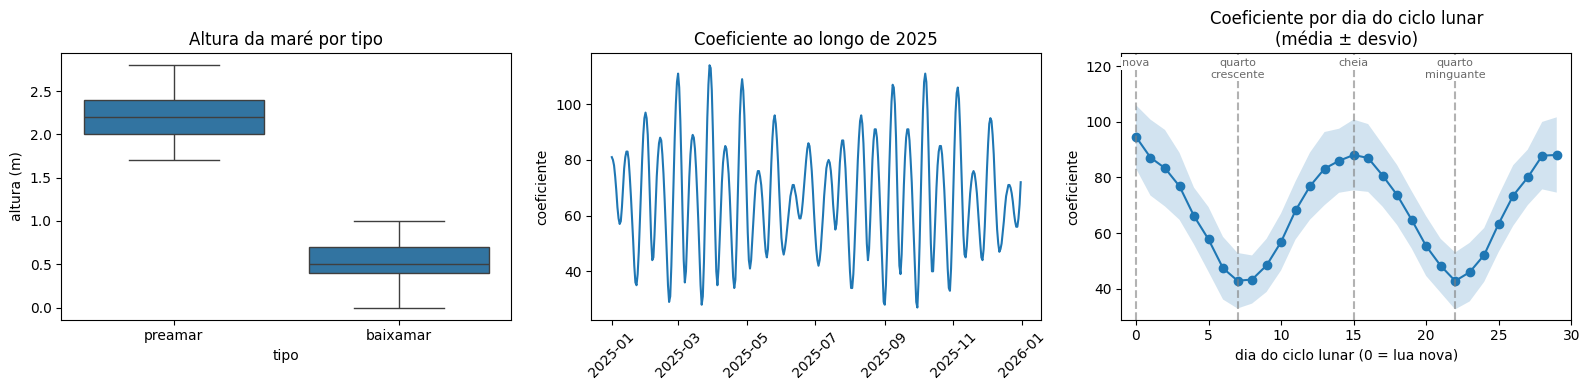

          count  mean   std  min  25%  50%  75%  max
tipo                                                
baixamar  705.0  0.54  0.22  0.0  0.4  0.5  0.7  1.0
preamar   705.0  2.20  0.24  1.7  2.0  2.2  2.4  2.8
correlação linear coeficiente x dia_lunar: 0.02
correlação coeficiente x ciclo da lua: 0.83
correlação coeficiente x preamar: 0.97
correlação coeficiente x baixamar: -0.95
coeficiente: média 67 | mín 27 | máx 114
coeficiente médio nos dias lunares 0, 7, 15 e 22: {0: 95.0, 7: 43.0, 15: 88.0, 22: 43.0}
desvio médio do coeficiente dentro de cada dia lunar: 11.1


In [6]:
fig, eixos = plt.subplots(1, 3, figsize=(16, 4))

sns.boxplot(data=mares_2025, x="tipo", y="altura", ax=eixos[0])
eixos[0].set_title("Altura da maré por tipo")
eixos[0].set_ylabel("altura (m)")

dias = mares_2025.drop_duplicates("data").copy()
dias["data"] = pd.to_datetime(dias["data"])

eixos[1].plot(dias["data"], dias["coeficiente"])
eixos[1].set_title("Coeficiente ao longo de 2025")
eixos[1].set_ylabel("coeficiente")
eixos[1].tick_params(axis="x", rotation=45)

por_fase = dias.groupby("dia_lunar")["coeficiente"].agg(["mean", "std"])
eixos[2].plot(por_fase.index, por_fase["mean"], marker="o")
eixos[2].fill_between(por_fase.index, por_fase["mean"] - por_fase["std"],
                      por_fase["mean"] + por_fase["std"], alpha=0.2)
eixos[2].set_title("Coeficiente por dia do ciclo lunar\n(média ± desvio)")
eixos[2].set_ylabel("coeficiente")
eixos[2].set_xlabel("dia do ciclo lunar (0 = lua nova)")
eixos[2].set_xlim(-1, 30)
eixos[2].set_ylim(top=eixos[2].get_ylim()[1] + 15)
for dia_fase, nome in [(0, "nova"), (7, "quarto\ncrescente"), (15, "cheia"), (22, "quarto\nminguante")]:
    eixos[2].axvline(dia_fase, color="gray", linestyle="--", alpha=0.6)
    eixos[2].text(dia_fase, 0.98, nome, transform=eixos[2].get_xaxis_transform(),
                  ha="center", va="top", fontsize=8, color="dimgray",
                  bbox=dict(facecolor="white", edgecolor="none", pad=1))

plt.tight_layout()
plt.show()

print(mares_2025.groupby("tipo")["altura"].describe().round(2))
print("correlação linear coeficiente x dia_lunar:", round(dias["coeficiente"].corr(dias["dia_lunar"]), 2))

ciclo_lua = np.cos(4 * np.pi * dias["dia_lunar"] / 29.5)
print("correlação coeficiente x ciclo da lua:", round(dias["coeficiente"].corr(ciclo_lua), 2))

coef_dia = mares_2025.drop_duplicates("data").set_index("data")["coeficiente"]
preamar_dia = mares_2025[mares_2025["tipo"] == "preamar"].groupby("data")["altura"].max()
baixamar_dia = mares_2025[mares_2025["tipo"] == "baixamar"].groupby("data")["altura"].min()
print("correlação coeficiente x preamar:", round(coef_dia.corr(preamar_dia), 2))
print("correlação coeficiente x baixamar:", round(coef_dia.corr(baixamar_dia), 2))

print("coeficiente: média", round(dias["coeficiente"].mean()), "| mín", dias["coeficiente"].min(), "| máx", dias["coeficiente"].max())
print("coeficiente médio nos dias lunares 0, 7, 15 e 22:", por_fase["mean"].loc[[0, 7, 15, 22]].round(0).to_dict())
print("desvio médio do coeficiente dentro de cada dia lunar:", round(por_fase["std"].mean(), 1))

**Leitura dos gráficos de marés**

1. **Altura por tipo:** as duas distribuições quase não se sobrepõem. A baixamar fica em torno de 0,5 m (de 0,0 a 1,0 m) e a preamar em torno de 2,2 m (de 1,7 a 2,8 m).
2. **Coeficiente ao longo de 2025:** varia entre 27 e 114, com média de 67. Ele **oscila em ciclos** o ano todo (cerca de uma volta a cada 15 dias), sem tendência de subir ou descer.
3. **Coeficiente por dia do ciclo lunar:** o eixo vai de 0 a 29 (0 = lua nova, ~15 = cheia) e cada ponto é um dia do ciclo, não uma fase; as linhas tracejadas marcam as 4 fases. Há dois picos, perto do dia 0 (95) e do dia 15 (88), e dois vales, perto dos dias 7 e 8 (43) e 22 (43). Isso combina com marés mais fortes na lua nova e na cheia. A faixa sombreada (média ± desvio) mostra que a fase explica boa parte do coeficiente, mas não tudo: dentro de cada fase os dias variam uns 11 pontos.

A correlação linear entre coeficiente e `dia_lunar` deu 0,02, quase nada. Isso não quer dizer que não haja relação: a relação é **cíclica** (sobe, desce, sobe, desce), e a correlação linear não enxerga ciclos. Usando uma medida que respeita o ciclo (cosseno com dois picos por mês lunar), a correlação sobe para **0,83**.

O coeficiente também acompanha de perto o tamanho da maré do dia: correlação de **0,97** com a altura da preamar e de **-0,95** com a da baixamar. Quanto maior o coeficiente, mais alta a preamar e mais baixa a baixamar.

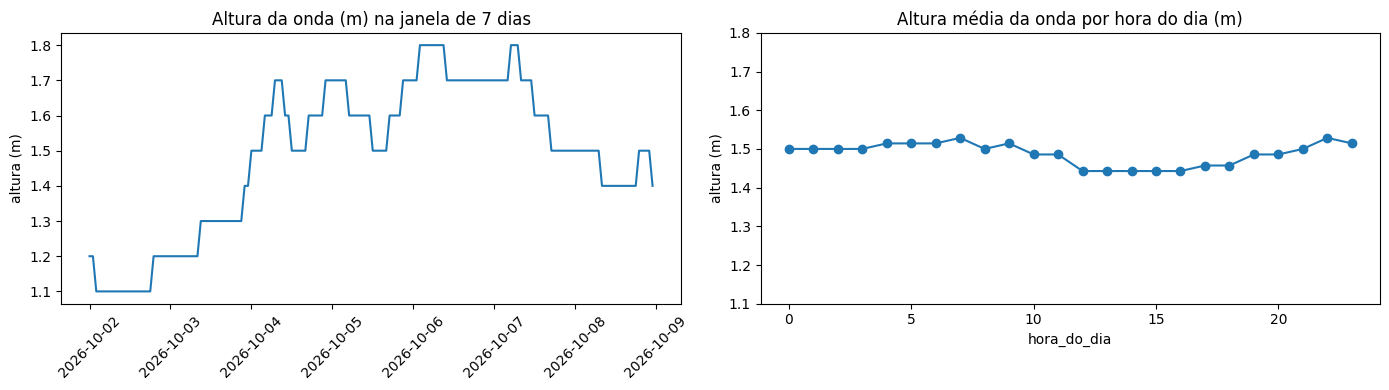

count    168.00
mean       1.49
std        0.21
min        1.10
25%        1.30
50%        1.50
75%        1.70
max        1.80
Name: altura_onda, dtype: float64
média por hora do dia (mín e máx): {'min': 1.44, 'max': 1.53}
data  2026-10-02  2026-10-03  2026-10-04  2026-10-05  2026-10-06  2026-10-07  \
min          1.1         1.2         1.5         1.5         1.7         1.5   
max          1.2         1.4         1.7         1.7         1.8         1.8   

data  2026-10-08  
min          1.4  
max          1.5  


In [7]:
fig, eixos = plt.subplots(1, 2, figsize=(14, 4))

eixos[0].plot(ondas["data_hora"], ondas["altura_onda"])
eixos[0].set_title("Altura da onda (m) na janela de 7 dias")
eixos[0].set_ylabel("altura (m)")
eixos[0].tick_params(axis="x", rotation=45)

ondas.groupby("hora_do_dia")["altura_onda"].mean().plot(ax=eixos[1], marker="o")
eixos[1].set_ylim(ondas["altura_onda"].min(), ondas["altura_onda"].max())
eixos[1].set_title("Altura média da onda por hora do dia (m)")
eixos[1].set_ylabel("altura (m)")

plt.tight_layout()
plt.show()

print(ondas["altura_onda"].describe().round(2))
print("média por hora do dia (mín e máx):",
      ondas.groupby("hora_do_dia")["altura_onda"].mean().agg(["min", "max"]).round(2).to_dict())
print(ondas.groupby("data")["altura_onda"].agg(["min", "max"]).T)

**Leitura dos gráficos de ondas**

1. **Faixa de altura:** de 1,1 a 1,8 m, média de 1,49 m. A altura **sobe ao longo da janela**: 1,1–1,2 m no dia 2 de outubro e 1,7–1,8 m no dia 6 (o dia 7 vai de 1,5 a 1,8 m).
2. **Por hora do dia:** a média por hora quase não muda (de 1,44 a 1,53 m). Isso é menos que o passo de 0,1 m com que o site informa a altura, então não dá para afirmar que existe padrão por hora. A variação é **por dia, não por hora do dia**.

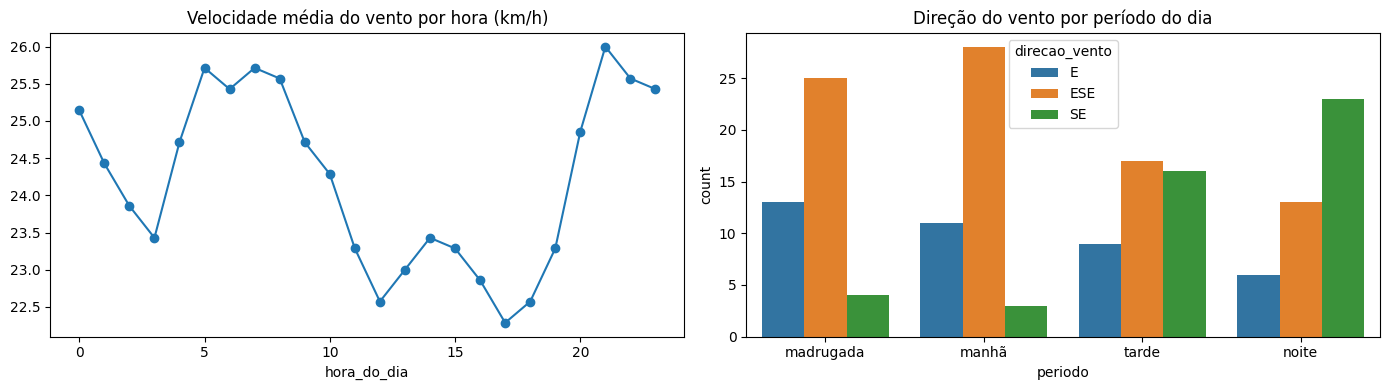

count    168.0
mean      24.2
std        3.5
min       13.0
25%       22.0
50%       24.0
75%       27.0
max       30.0
Name: velocidade_vento, dtype: float64
direcao_vento   E  ESE  SE
periodo                   
madrugada      13   25   4
manhã          11   28   3
tarde           9   17  16
noite           6   13  23


In [8]:
vento["periodo"] = pd.cut(vento["hora_do_dia"], bins=[-1, 5, 11, 17, 23],
                          labels=["madrugada", "manhã", "tarde", "noite"])

fig, eixos = plt.subplots(1, 2, figsize=(14, 4))


vento.groupby("hora_do_dia")["velocidade_vento"].mean().plot(ax=eixos[0], marker="o")
eixos[0].set_title("Velocidade média do vento por hora (km/h)")

sns.countplot(data=vento, x="periodo", hue="direcao_vento", ax=eixos[1])
eixos[1].set_title("Direção do vento por período do dia")

plt.tight_layout()
plt.show()

print(vento["velocidade_vento"].describe().round(1))
print(pd.crosstab(vento["periodo"], vento["direcao_vento"]))

**Leitura dos gráficos de vento**

1. **Velocidade por hora:** o vento varia de 13 a 30 km/h (média de 24). As horas mais calmas ficam em torno de 12h e 17h (cerca de 22 km/h), e a mais forte é por volta das 21h (cerca de 26 km/h). A diferença entre as horas é pequena, de uns 4 km/h.
2. **Direção por período:** de madrugada e de manhã predomina `ESE`. À tarde e à noite o `SE` cresce muito (à noite são 23 `SE` contra 13 `ESE`). Ou seja, a direção **muda ao longo do dia**.

**Vento da terra ou do mar?**

A direção do vento indica **de onde ele vem**. A orla de João Pessoa fica voltada para o leste. Então `E`, `ESE` e `SE` vêm do **mar**: são ventos *onshore* (do mar para a terra), e o `SE` tende a ser mais cruzado com a praia. Nos 168 horários da janela **não há nenhum vento de terra** (*offshore*, de oeste).

Para a onda: em surf, vento do mar costuma deixar o mar mais mexido e menos organizado, e o vento de terra costuma "limpar" a onda.

## 4. Juntar as tabelas

Esta é a parte difícil, e ela tem mais de uma resposta certa.

As granularidades não batem: onda e vento são leituras horárias; maré são ~4
eventos por dia (os instantes de máxima e mínima). Para ter uma linha por hora
com as três informações você precisa decidir:

- Como levar a maré para a grade horária? Interpolar entre eventos? Repetir o
  último valor? Guardar apenas se a maré está subindo ou descendo? O que cada
  escolha assume sobre a curva real da maré — e onde essa suposição erra?
- Qual o tipo de junção? A previsão de onda e a de vento cobrem exatamente as
  mesmas horas? Se não, você mantém as horas incompletas ou corta?
- Que variáveis derivadas de tempo ajudam a responder a pergunta do projeto
  (dia da semana, período do dia, ...)?

Justifique as escolhas em markdown. Elas são a base das duas próximas etapas.

In [9]:
horas = pd.date_range(ondas["data_hora"].min(), ondas["data_hora"].max(), freq="h")

eventos = mares_mes.set_index("data_hora")["altura"]

linha = eventos.reindex(eventos.index.union(horas)).interpolate(method="time")
mare_horaria = linha.loc[horas].rename("altura_mare").to_frame()
mare_horaria.index.name = "data_hora"


print(mare_horaria.shape, "| nulos:", int(mare_horaria.isna().sum().sum()))
mare_horaria.head(8)

(168, 1) | nulos: 0


,altura_mare
data_hora,
2026-10-02 00:00:00,0.814058
2026-10-02 01:00:00,0.559416
2026-10-02 02:00:00,0.691169
2026-10-02 03:00:00,0.940519
2026-10-02 04:00:00,1.189870
2026-10-02 05:00:00,1.439221
2026-10-02 06:00:00,1.688571
2026-10-02 07:00:00,1.937922


**Justificativa: como levei a maré para a grade horária**

Onda e vento têm uma leitura por hora, mas a maré só tem ~4 eventos por dia (as preamares e baixamares). Escolhi **interpolar no tempo** entre os eventos para ter uma altura de maré em cada hora cheia (`altura_mare`).

- **O que isso supõe:** que a água sobe e desce a uma velocidade constante entre uma baixamar e uma preamar.
- **Onde erra:** a maré real é uma curva suave, devagar perto dos picos e rápida no meio. A interpolação linear passa pelos eventos reais, então erra mais **entre** eles, perto de 1/4 e 3/4 do caminho: subestima a altura perto das preamares e superestima perto das baixamares (comparação na célula seguinte).

diferença absoluta entre os dois métodos (m):
count    168.000
mean       0.103
std        0.055
min        0.003
25%        0.061
50%        0.104
75%        0.136
max        0.232
dtype: float64
maior diferença em: 2026-10-08 22:00:00 | linear: 0.79 | cosseno: 0.56
correlação onda x maré com linear: -0.002
correlação onda x maré com cosseno: -0.001


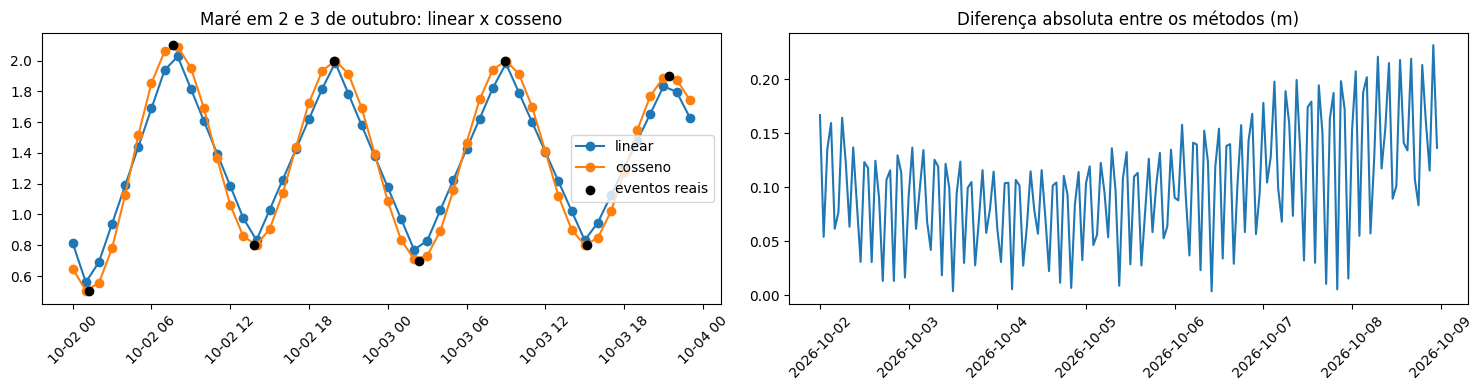

In [10]:
import numpy as np


def interpola_cosseno(eventos, horas):
    t = eventos.index.values.astype("int64")
    h = eventos.values
    x = horas.values.astype("int64")
    i = (np.searchsorted(t, x, side="right") - 1).clip(0, len(t) - 2)
    s = (x - t[i]) / (t[i + 1] - t[i])
    return h[i] + (h[i + 1] - h[i]) * (1 - np.cos(np.pi * s)) / 2


linear = mare_horaria["altura_mare"]
cosseno = pd.Series(interpola_cosseno(eventos, horas), index=horas)
diferenca = (cosseno - linear).abs()

print("diferença absoluta entre os dois métodos (m):")
print(diferenca.describe().round(3))
print("maior diferença em:", diferenca.idxmax(), "| linear:", round(linear[diferenca.idxmax()], 2),
      "| cosseno:", round(cosseno[diferenca.idxmax()], 2))

onda = ondas["altura_onda"].reset_index(drop=True)
print("correlação onda x maré com linear:", round(onda.corr(linear.reset_index(drop=True)), 3))
print("correlação onda x maré com cosseno:", round(onda.corr(cosseno.reset_index(drop=True)), 3))

dia = slice("2026-10-02", "2026-10-03")
fig, eixos = plt.subplots(1, 2, figsize=(15, 4))
eixos[0].plot(linear.loc[dia], marker="o", label="linear")
eixos[0].plot(cosseno.loc[dia], marker="o", label="cosseno")
eventos_dia = eventos.loc["2026-10-02":"2026-10-03 23:59"]
eixos[0].scatter(eventos_dia.index, eventos_dia.values, color="black", zorder=5, label="eventos reais")
eixos[0].set_title("Maré em 2 e 3 de outubro: linear x cosseno")
eixos[0].tick_params(axis="x", rotation=45)
eixos[0].legend()

eixos[1].plot(diferenca)
eixos[1].set_title("Diferença absoluta entre os métodos (m)")
eixos[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

**Comparação: interpolação linear x cosseno**

Comparei a interpolação linear (usada no `dataset`) com uma interpolação em forma de cosseno entre cada par de eventos (baixamar e preamar). O cosseno tem inclinação zero nos picos e é mais rápido no meio, que é a forma aproximada da maré real.

- **Diferença entre os dois métodos:** média de **0,10 m**, e a máxima de **0,23 m** (em 8/10 às 22h: linear 0,79 m contra cosseno 0,56 m). Perto de uma maré de ~1,9 m de amplitude, isso é cerca de 5% na média.
- **Onde diferem:** nos pontos entre um evento e o seguinte, principalmente a ~1/4 e ~3/4 do caminho. Nos próprios eventos os dois coincidem, porque ambos passam pelos pontos reais.
- **Muda a conclusão?** Não. A correlação entre onda e maré é praticamente zero nos dois casos (-0,002 com linear e -0,001 com cosseno).
- **Qual está mais certo?** Como a maré real é uma curva suave, achatada nos picos, o cosseno é uma aproximação mais plausível que a linear. Não foi possível medir qual é mais precisa, porque o site não publica a altura da maré hora a hora.

In [11]:
print("mesmas horas?", set(ondas["data_hora"]) == set(vento["data_hora"]))

clima = ondas.merge(
    vento[["data_hora", "velocidade_vento", "direcao_vento"]],
    on="data_hora",
    how="inner",
)
print(clima.shape)
clima.head(3)

mesmas horas? True
(168, 8)


,data,hora,altura_onda,direcao_onda,data_hora,hora_do_dia,velocidade_vento,direcao_vento
0,2026-10-02,0:00,1.2,E,2026-10-02 00:00:00,0,25,E
1,2026-10-02,1:00,1.2,E,2026-10-02 01:00:00,1,23,E
2,2026-10-02,2:00,1.1,E,2026-10-02 02:00:00,2,22,E


In [12]:
dataset = clima.merge(mare_horaria.reset_index(), on="data_hora", how="left")

dias_mare = mares_mes.drop_duplicates("data")[["data", "coeficiente", "dia_lunar"]]
dataset = dataset.merge(dias_mare, on="data", how="left")

dataset["dia_semana"] = dataset["data_hora"].dt.dayofweek
dataset["periodo"] = pd.cut(dataset["hora_do_dia"], bins=[-1, 5, 11, 17, 23],
                            labels=["madrugada", "manhã", "tarde", "noite"])

print(dataset.shape, "| nulos:", int(dataset.isna().sum().sum()))
dataset.head()

(168, 13) | nulos: 0


,data,hora,altura_onda,direcao_onda,data_hora,hora_do_dia,velocidade_vento,direcao_vento,altura_mare,coeficiente,dia_lunar,dia_semana,periodo
0,2026-10-02,0:00,1.2,E,2026-10-02 00:00:00,0,25,E,0.814058,50,20,4,madrugada
1,2026-10-02,1:00,1.2,E,2026-10-02 01:00:00,1,23,E,0.559416,50,20,4,madrugada
2,2026-10-02,2:00,1.1,E,2026-10-02 02:00:00,2,22,E,0.691169,50,20,4,madrugada
3,2026-10-02,3:00,1.1,E,2026-10-02 03:00:00,3,22,E,0.940519,50,20,4,madrugada
4,2026-10-02,4:00,1.1,E,2026-10-02 04:00:00,4,21,E,1.189870,50,20,4,madrugada


**Justificativa: junção das tabelas e variáveis de tempo**

- **Ondas com vento:** as duas previsões cobrem exatamente as mesmas 168 horas (conferido no código), então usei `inner` e não perdi nenhuma linha. Se as janelas fossem diferentes, essa escolha perderia linhas.
- **Com a maré:** usei `left` a partir de ondas e vento, para manter todas as horas de previsão e só acrescentar a maré.
- **`coeficiente` e `dia_lunar`:** são valores do dia, então juntei pela data. Ficam iguais nas 24 horas.
- **Variáveis de tempo:** `hora_do_dia`, `dia_semana` (0 é segunda) e `periodo` (madrugada, manhã, tarde, noite), porque o objetivo do projeto é achar os melhores **dias e horários**.

Resultado: `dataset` com 168 linhas, 13 colunas e nenhum nulo (`data` e `hora` saem só na hora de salvar, seção 6).

## 5. Visualizações voltadas à pergunta

Agora com a tabela junta: quando as condições coincidem?

- As horas de onda maior são as mesmas de vento mais fraco, ou elas se
  desencontram?
- Existe relação visível entre altura da maré e altura da onda?
- Quais dias e horas da janela se destacam?

Prefira poucos gráficos legíveis a muitos gráficos.

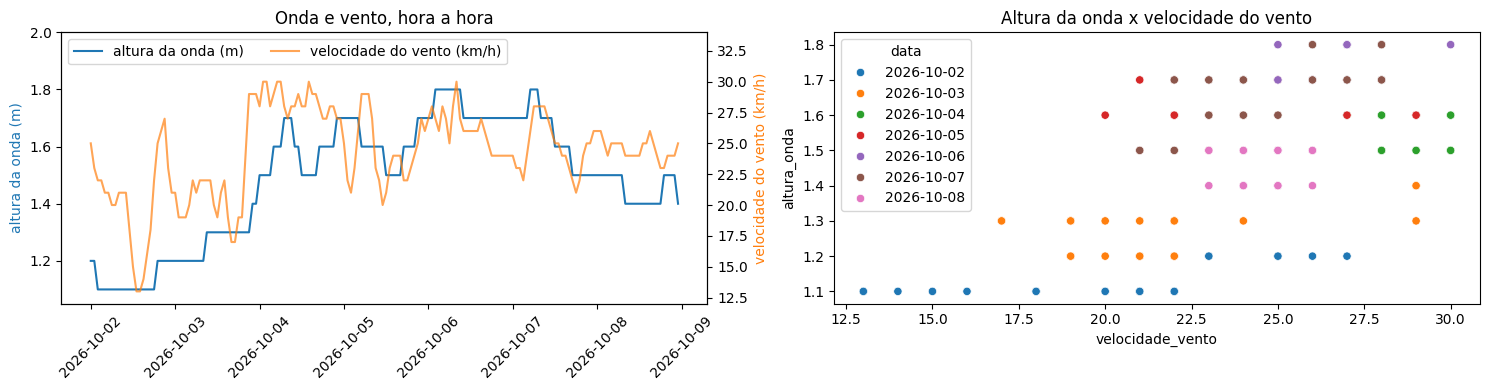

correlação onda x vento: 0.63
correlação entre dias (médias diárias): 0.82
correlação dentro do dia: 0.31
correlação onda x vento em cada dia:
data
2026-10-02    0.66
2026-10-03    0.46
2026-10-04   -0.51
2026-10-05    0.14
2026-10-06    0.55
2026-10-07    0.52
2026-10-08    0.15
dtype: float64


In [13]:
fig, eixos = plt.subplots(1, 2, figsize=(15, 4))

linha_onda, = eixos[0].plot(dataset["data_hora"], dataset["altura_onda"], color="tab:blue",
                            label="altura da onda (m)")
eixos[0].set_ylabel("altura da onda (m)", color="tab:blue")
eixo_vento = eixos[0].twinx()
linha_vento, = eixo_vento.plot(dataset["data_hora"], dataset["velocidade_vento"], color="tab:orange",
                               alpha=0.7, label="velocidade do vento (km/h)")
eixo_vento.set_ylabel("velocidade do vento (km/h)", color="tab:orange")
eixos[0].set_title("Onda e vento, hora a hora")
eixos[0].tick_params(axis="x", rotation=45)
eixos[0].set_ylim(1.05, 2.0)
eixo_vento.set_ylim(12, 34)
eixos[0].legend(handles=[linha_onda, linha_vento], loc="upper left", ncol=2)

sns.scatterplot(data=dataset, x="velocidade_vento", y="altura_onda", hue="data", ax=eixos[1])
eixos[1].set_title("Altura da onda x velocidade do vento")

plt.tight_layout()
plt.show()

print("correlação onda x vento:", round(dataset["altura_onda"].corr(dataset["velocidade_vento"]), 2))

medias_dia = dataset.groupby("data")[["altura_onda", "velocidade_vento"]].mean()
print("correlação entre dias (médias diárias):", round(medias_dia["altura_onda"].corr(medias_dia["velocidade_vento"]), 2))

onda_sem_dia = dataset["altura_onda"] - dataset.groupby("data")["altura_onda"].transform("mean")
vento_sem_dia = dataset["velocidade_vento"] - dataset.groupby("data")["velocidade_vento"].transform("mean")
print("correlação dentro do dia:", round(onda_sem_dia.corr(vento_sem_dia), 2))

por_dia = dataset.groupby("data").apply(
    lambda g: g["altura_onda"].corr(g["velocidade_vento"]), include_groups=False)
print("correlação onda x vento em cada dia:")
print(por_dia.round(2))

**Leitura: onda e vento**

Onda e vento tendem a subir juntos, mas só na escala da semana. A correlação geral entre altura da onda e velocidade do vento é de **0,63**. Separando em dois níveis:

- **Entre dias:** **0,82**. Ao longo da semana, onda e vento sobem juntos (do dia 2 ao dia 4, os dois crescem). São só 7 pontos, então esse número é frágil.
- **Dentro do dia:** **0,31**, bem mais fraco. No gráfico de dispersão, os pontos se agrupam por dia (cada cor forma uma nuvem quase plana), e em um dia, o 4, a relação chega a ser negativa (-0,51).

Ou seja, "andam juntos" vale para a tendência da semana, e não para cada hora. Para a pergunta do projeto: os dias de onda maior também têm vento mais forte, o que pode piorar a condição para surfar, mas escolher a **hora** dentro de um dia não é muito limitado pelo vento.

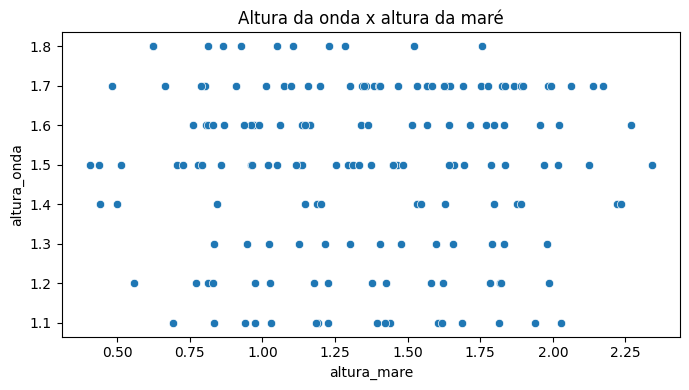

correlação onda x maré: -0.0


In [14]:
plt.figure(figsize=(7, 4))
sns.scatterplot(data=dataset, x="altura_mare", y="altura_onda")
plt.title("Altura da onda x altura da maré")

plt.tight_layout()
plt.show()

print("correlação onda x maré:", round(dataset["altura_onda"].corr(dataset["altura_mare"]), 2))

**Leitura: maré e onda**

**Não há relação visível** entre a altura da maré e a altura da onda nesta janela. A correlação é praticamente zero. No gráfico os pontos ficam espalhados sem formar tendência.

Ressalva: são só 7 dias, e a altura da maré em cada hora vem de interpolação (ver seção 4), então isso não prova que a maré não influencia a onda, só que não aparece nestes dados.

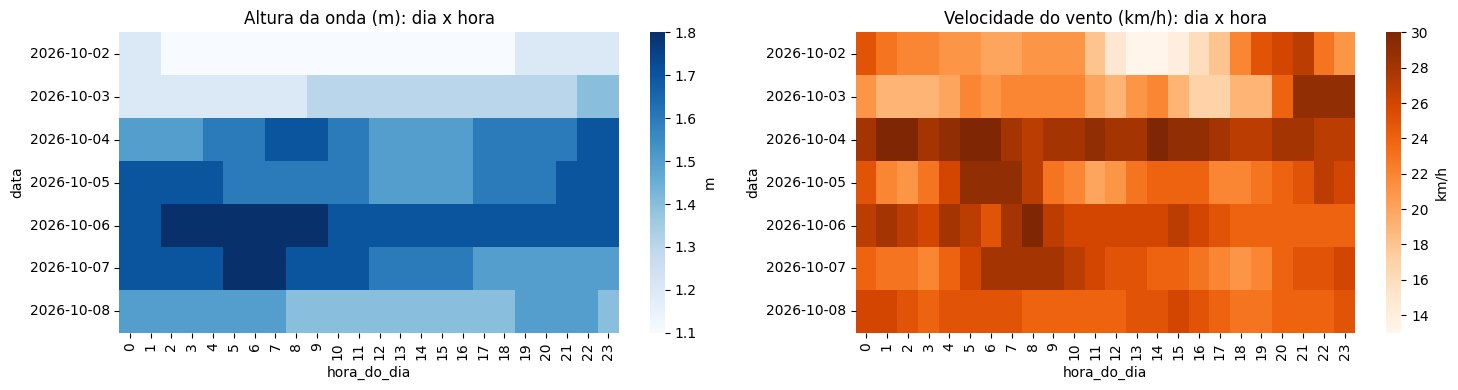

            altura_onda  velocidade_vento
data                                     
2026-10-02         1.13             20.33
2026-10-03         1.27             21.38
2026-10-04         1.58             28.38
2026-10-05         1.61             24.21
2026-10-06         1.73             26.04
2026-10-07         1.63             24.71
2026-10-08         1.45             24.54
altura_onda: variação entre dias = 0.22 | dentro do dia = 0.07
velocidade_vento: variação entre dias = 2.71 | dentro do dia = 2.21


In [15]:
fig, eixos = plt.subplots(1, 2, figsize=(15, 4))

onda_hm = dataset.pivot_table(index="data", columns="hora_do_dia", values="altura_onda")
sns.heatmap(onda_hm, cmap="Blues", ax=eixos[0], cbar_kws={"label": "m"})
eixos[0].set_title("Altura da onda (m): dia x hora")

vento_hm = dataset.pivot_table(index="data", columns="hora_do_dia", values="velocidade_vento")
sns.heatmap(vento_hm, cmap="Oranges", ax=eixos[1], cbar_kws={"label": "km/h"})
eixos[1].set_title("Velocidade do vento (km/h): dia x hora")

plt.tight_layout()
plt.show()

print(dataset.groupby("data")[["altura_onda", "velocidade_vento"]].mean().round(2))

for col in ["altura_onda", "velocidade_vento"]:
    entre = dataset.groupby("data")[col].mean().std()
    dentro = dataset.groupby("data")[col].std().mean()
    print(f"{col}: variação entre dias = {entre:.2f} | dentro do dia = {dentro:.2f}")

**Leitura: dias e horas que se destacam**

- **Dias:** a onda cresce de 1,13 m (média do dia 2) até **1,73 m no dia 6** e volta a 1,45 m no dia 8. O vento é mais forte no **dia 4 (28 km/h de média)** e mais fraco no dia 2 (20 km/h).
- **Horas:** na **onda**, a variação é principalmente por dia (desvio entre dias 0,22 m contra 0,07 m dentro do dia). No **vento**, a hora conta quase tanto quanto o dia (2,71 km/h entre dias contra 2,21 km/h dentro do dia).

## 6. Salvar o dataset processado

Grave o resultado em `../data/processed/dataset.csv`. A Etapa 3 lê esse
arquivo — se as colunas mudarem depois, o notebook de ML muda também.

In [16]:
dataset.drop(columns=["data", "hora"]).to_csv(DIR_PROC / "dataset.csv", index=False)

conferir = pd.read_csv(DIR_PROC / "dataset.csv")
print("dataset.csv:", conferir.shape, "| nulos:", int(conferir.isna().sum().sum()))
print(list(conferir.columns))

dataset.csv: (168, 11) | nulos: 0
['altura_onda', 'direcao_onda', 'data_hora', 'hora_do_dia', 'velocidade_vento', 'direcao_vento', 'altura_mare', 'coeficiente', 'dia_lunar', 'dia_semana', 'periodo']


O dataset foi salvo em `../data/processed/dataset.csv` com **168 linhas e 11 colunas, sem nulos**. Conferi lendo o arquivo de volta. Deixei de fora `data` e `hora`, que são texto repetido de `data_hora`; assim a Etapa 3 tem `data_hora` como identificador e `hora_do_dia` como variável, e é mais difícil usar a data sem perceber. Se o notebook de ML mudar as colunas usadas, é só ajustar lá.

## 7. Conclusões

Em texto, sem código:

1. O que os dados mostram sobre as condições da janela coletada?
2. Que decisão de limpeza ou de junção você tomou que mais influencia o
   resultado, e por quê?
3. O que esses dados **não** permitem afirmar?

**Conclusões**

1. **O que os dados mostram:** na janela de 2 a 8 de outubro de 2026, a onda sobe de cerca de 1,1 m no dia 2 até o pico de 1,8 m no dia 6 (média do dia: 1,73 m) e depois cai. O vento fica entre 13 e 30 km/h (média de 24) e é mais forte no dia 4. Onda e vento sobem juntos ao longo da semana (correlação de 0,82 entre dias), mas dentro de um mesmo dia a relação é fraca (0,31), e a maré não mostra relação com a altura da onda. O vento muda de direção ao longo do dia, de `ESE` de manhã para `SE` à tarde e à noite.
2. **A decisão que mais influencia o resultado:** levar a maré para a grade horária por interpolação linear (seção 4). A maré é a única variável que não tem leitura de hora em hora, então tudo o que depende dela na Etapa 3 depende dessa suposição. Nesta janela ela pouco afetou as conclusões, porque a maré não se relacionou com a onda.
3. **O que os dados não permitem afirmar:** (a) nada sobre a melhor **época do ano**, já que onda e vento só cobrem 7 dias; (b) que a previsão aconteça de fato, porque são previsões e não medições; (c) causa e efeito, pois a correlação onda x vento mostra que andam juntos, mas não por quê.